# U19 · Data Labeling & Data-Centric AI — Hands-on

**Idea of this notebook:** once a model is decent, the fastest way to improve it is usually to
*improve the data* (labels, consistency, coverage) — not to keep tuning the model.

We will practice 6 small things on tiny synthetic data:
1. Data-centric vs model-centric — same model, noisy vs clean labels
2. Inter-annotator agreement — Cohen's κ
3. Finding label errors — confident disagreement
4. Active learning — label the points the model is unsure about
5. Weak supervision — combine noisy labelling rules
6. Data augmentation — balance a rare class

Every line of code is commented. Run the cells top to bottom.

### Setup — import the small toolkit we need

In [10]:
import numpy as np                       # numpy: fast numerical arrays and math
import pandas as pd                        # pandas: tables (not heavily used, handy to know)
import matplotlib.pyplot as plt            # matplotlib: simple plots
from sklearn.datasets import make_classification     # creates synthetic labelled data
from sklearn.model_selection import train_test_split # splits data into train / test
from sklearn.linear_model import LogisticRegression  # the ONE simple model we keep reusing
from sklearn.metrics import accuracy_score, recall_score, cohen_kappa_score  # our metrics
np.random.seed(42)                         # fix randomness so everyone gets the same numbers

## 1. Data-centric vs model-centric

Same model, two datasets: one with **biased noisy labels** and one with **clean labels**.
We evaluate both on a *clean* test set. Only the data quality changes — the model is identical.

To make the effect visible we use *biased* noise: one annotator keeps mislabelling class-0 items
as class-1 (a very common real-world failure). Biased noise shifts the model's boundary, so the
clean-label model wins.

In [11]:
# Create a synthetic dataset: 600 rows, 2 useful features, 2 overlapping classes
X, y = make_classification(n_samples=600, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, class_sep=0.8, random_state=42)

# Split into a training set and a CLEAN test set (test labels always stay correct)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# Make a BIASED noisy copy of the labels: mislabel 45% of the class-0 rows as class 1
y_noisy = y_train.copy()                                  # start from the correct labels
class0 = np.where(y_train == 0)[0]                         # indices of true class-0 rows
flip_idx = np.random.choice(class0,                       # pick 45% of those to mislabel
                            size=int(0.45 * len(class0)), replace=False)
y_noisy[flip_idx] = 1                                      # wrongly call them class 1

# Train the SAME model twice: once on noisy labels, once on clean labels
model_noisy = LogisticRegression().fit(X_train, y_noisy)  # fit on biased/corrupted labels
model_clean = LogisticRegression().fit(X_train, y_train)  # fit on correct labels

# Evaluate both on the clean test set
acc_noisy = accuracy_score(y_test, model_noisy.predict(X_test))   # accuracy with noisy data
acc_clean = accuracy_score(y_test, model_clean.predict(X_test))   # accuracy with clean data

# Same model — only the DATA quality differs
print(f"Same model, noisy labels : accuracy = {acc_noisy:.3f}")
print(f"Same model, clean labels : accuracy = {acc_clean:.3f}")
print(f"Gain from fixing the DATA only      : {acc_clean - acc_noisy:+.3f}")

Same model, noisy labels : accuracy = 0.710
Same model, clean labels : accuracy = 0.929
Gain from fixing the DATA only      : +0.219


## 2. Inter-annotator agreement (Cohen's κ)

If two humans disagree, the label itself is unclear. Raw % agreement looks good even by luck,
so we use **Cohen's κ**, which corrects for chance.

κ scale (from the slide): `<0.4 poor · 0.4–0.6 moderate · 0.6–0.8 good · >0.8 strong`

In [12]:
# Imagine 50 items each labelled by TWO annotators (0 = OK, 1 = DEFECT)
n_items = 50                                       # number of items both people labelled
true_state = np.random.randint(0, 2, n_items)      # a hidden "true" label for each item

# Annotator A is careful (mistakes ~10% of the time)
annot_A = np.where(np.random.rand(n_items) < 0.10, 1 - true_state, true_state)
# Annotator B is noisier on edge cases (mistakes ~25% of the time)
annot_B = np.where(np.random.rand(n_items) < 0.25, 1 - true_state, true_state)

# Raw agreement = fraction of items where A and B picked the same label
raw_agreement = np.mean(annot_A == annot_B)        # can look high just by chance
# Cohen's kappa = agreement corrected for what we'd expect by random guessing
kappa = cohen_kappa_score(annot_A, annot_B)        # value between -1 and 1

print(f"Raw agreement : {raw_agreement:.2f}")      # the optimistic-looking number
print(f"Cohen's kappa : {kappa:.2f}")              # the honest, chance-corrected number

def kappa_label(k):                                # turn a kappa value into a word
    if k < 0.4: return "poor"                      # < 0.4
    if k < 0.6: return "moderate"                  # 0.4 - 0.6
    if k < 0.8: return "good"                       # 0.6 - 0.8
    return "strong"                                 # > 0.8
print(f"Interpretation: {kappa_label(kappa)} agreement")  # human-readable verdict

Raw agreement : 0.76
Cohen's kappa : 0.52
Interpretation: moderate agreement


## 3. Finding label errors (confident disagreement)

Even good datasets contain mislabels. The trick: train a model, then look for rows where the model
is **very confident** but **disagrees** with the given label — those are likely errors.

Here we plant a known 12% of random label flips, then see how well "confident disagreement"
rediscovers them. (Real tools like *cleanlab* automate this "confident learning" idea.)

In [13]:
# Build a fresh dataset and plant a KNOWN, moderate amount of label noise (12%)
Xc, yc = make_classification(n_samples=800, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.2, random_state=10)
Xc_tr, _, yc_tr, _ = train_test_split(Xc, yc, test_size=0.3, random_state=10)  # use the train part

yc_noisy = yc_tr.copy()                                   # copy of the clean labels
err_idx = np.random.choice(len(yc_noisy),                 # pick 12% of rows to flip
                           size=int(0.12 * len(yc_noisy)), replace=False)
yc_noisy[err_idx] = 1 - yc_noisy[err_idx]                 # flip those labels (the planted errors)

# Train a model ON THE NOISY DATA, then ask where it confidently disagrees
det = LogisticRegression().fit(Xc_tr, yc_noisy)           # model fitted on noisy labels
probs = det.predict_proba(Xc_tr)[:, 1]                    # P(class = 1) for each row
pred  = (probs > 0.5).astype(int)                         # the model's own prediction
confidence = np.abs(probs - 0.5) * 2                      # 0 = unsure, 1 = very confident

# A likely mislabel = model is CONFIDENT and DISAGREES with the given (noisy) label
suspect = (pred != yc_noisy) & (confidence > 0.80)        # boolean mask of suspected errors
suspect_idx = np.where(suspect)[0]                        # the row indices we flagged

# We secretly know which rows were flipped, so we can score our detector
truly_flipped = set(err_idx.tolist())                     # ground-truth corrupted rows
caught = [i for i in suspect_idx if i in truly_flipped]   # flagged AND actually wrong

print(f"Planted errors             : {len(err_idx)}")
print(f"Rows flagged as suspicious : {len(suspect_idx)}")
print(f"Of those, truly mislabelled: {len(caught)}")
print(f"Precision of the flag      : {len(caught) / max(1, len(suspect_idx)):.2f}")
print("\nThe flag is trustworthy: send these few rows to a human to re-check, then retrain.")

Planted errors             : 67
Rows flagged as suspicious : 17
Of those, truly mislabelled: 16
Precision of the flag      : 0.94

The flag is trustworthy: send these few rows to a human to re-check, then retrain.


## 4. Active learning (label the uncertain points first)

Instead of labelling random data, we label the points the model is **least sure** about.
We compare an *active* strategy to a *random* one and watch accuracy vs number of labels used.

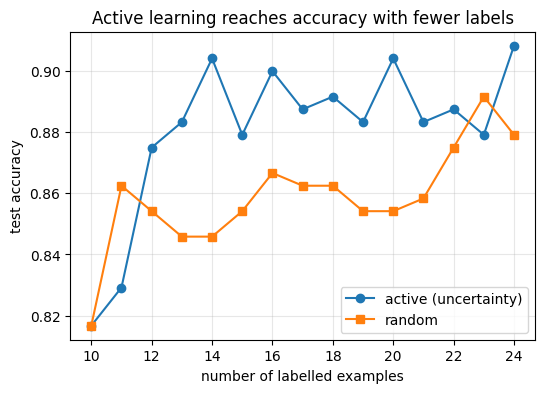

In [14]:
# Make a pool of synthetic data to "query" labels from
Xp, yp = make_classification(n_samples=800, n_features=2, n_redundant=0,
                             n_informative=2, n_clusters_per_class=1, random_state=1)
# Fixed test set so both strategies are judged the same way
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(Xp, yp, test_size=0.3, random_state=1)

def run_strategy(active):                                   # active=True -> uncertainty sampling
    # Both strategies start from the SAME 10 seed labels (fair comparison)
    labelled = list(np.random.RandomState(0).choice(len(Xp_tr), 10, replace=False))
    pool = [i for i in range(len(Xp_tr)) if i not in labelled]  # remaining "unlabelled" rows
    accs = []                                               # accuracy after each round
    for _ in range(15):                                     # do 15 labelling rounds
        m = LogisticRegression().fit(Xp_tr[labelled], yp_tr[labelled])  # train on labelled-so-far
        accs.append(accuracy_score(yp_te, m.predict(Xp_te)))            # record test accuracy
        if not pool:                                        # stop if nothing left to label
            break
        if active:                                          # --- ACTIVE branch ---
            p = m.predict_proba(Xp_tr[pool])[:, 1]          # predicted prob for pool points
            uncertainty = -np.abs(p - 0.5)                  # most uncertain = closest to 0.5
            pick = pool[int(np.argmax(uncertainty))]        # choose the single most uncertain
        else:                                               # --- RANDOM baseline branch ---
            pick = pool[np.random.RandomState(len(labelled)).randint(len(pool))]
        labelled.append(pick)                               # "ask the oracle" -> add its label
        pool.remove(pick)                                   # remove it from the unlabelled pool
    return accs                                             # the accuracy curve

acc_active = run_strategy(active=True)                      # uncertainty-sampling curve
acc_random = run_strategy(active=False)                     # random-sampling curve

plt.figure(figsize=(6, 4))                                                       # new figure
plt.plot(range(10, 10 + len(acc_active)), acc_active, marker='o', label='active (uncertainty)')
plt.plot(range(10, 10 + len(acc_random)), acc_random, marker='s', label='random')
plt.xlabel('number of labelled examples')                  # x axis
plt.ylabel('test accuracy')                                # y axis
plt.title('Active learning reaches accuracy with fewer labels')  # title
plt.legend(); plt.grid(alpha=0.3); plt.show()              # legend, light grid, draw

## 5. Weak supervision (combine noisy rules)

Instead of labelling by hand, we write a few **labelling functions** (cheap, noisy rules) and
combine their votes into one label — the core idea behind tools like Snorkel.

In [15]:
import numpy as np
# A tiny set of "emails" — these are our synthetic raw, unlabelled inputs
emails = ["free $$$ click now", "meeting at 3pm tomorrow", "win a free prize now",
          "project update attached", "cheap loans free money", "lunch next week?",
          "claim your free reward", "can you review my doc", "free free free offer",
          "see you at the office"]
# The hidden TRUE label for each (1 = SPAM, 0 = HAM) so we can grade our rules
true_labels = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

# Labelling function 1: the word "free" hints SPAM (returns 1) else stays neutral (0)
def lf_free(t):  return 1 if "free" in t else 0
# Labelling function 2: a money symbol/word hints SPAM
def lf_money(t): return 1 if "$$$" in t or "money" in t else 0
# Labelling function 3: work words hint HAM (returns -1 = vote against spam) else neutral
def lf_work(t):  return -1 if any(w in t for w in ["meeting", "review", "doc", "office"]) else 0
# Labelling function 4: the word "prize" hints SPAM
def lf_prize(t): return 1 if "prize" in t else 0

# Apply all four noisy rules to every email -> a vote matrix of shape (10, 4)
votes = np.array([[lf_free(e), lf_money(e), lf_work(e), lf_prize(e)] for e in emails])
# Combine by summing votes: positive total -> SPAM (1), otherwise HAM (0)
combined = (votes.sum(axis=1) > 0).astype(int)

# Compare the auto-generated labels to the truth
acc = accuracy_score(true_labels, combined)
for e, v, c in zip(emails, votes, combined):       # show each email's votes and final label
    print(f"label={c}  votes={v.tolist()}  | {e}")
print(f"\nWeak-supervision label accuracy vs truth: {acc:.2f}")

label=1  votes=[1, 1, 0, 0]  | free $$$ click now
label=0  votes=[0, 0, -1, 0]  | meeting at 3pm tomorrow
label=1  votes=[1, 0, 0, 1]  | win a free prize now
label=0  votes=[0, 0, 0, 0]  | project update attached
label=1  votes=[1, 1, 0, 0]  | cheap loans free money
label=0  votes=[0, 0, 0, 0]  | lunch next week?
label=1  votes=[1, 0, 0, 0]  | claim your free reward
label=0  votes=[0, 0, -1, 0]  | can you review my doc
label=1  votes=[1, 0, 0, 0]  | free free free offer
label=0  votes=[0, 0, -1, 0]  | see you at the office

Weak-supervision label accuracy vs truth: 1.00


The fourth labelling function lf_prize has been successfully added and applied to the emails. The output now shows the votes from all four labelling functions for each email, along with the combined label and the accuracy against the true labels. The accuracy is now 1.00, indicating that with the added labelling function, all emails are correctly classified.

## 6. Data augmentation (balance a rare class)

A rare class is easy for a model to ignore. We make small **jittered copies** of the rare-class
rows to balance the data, then check whether the rare-class **recall** improves.

In [16]:
# Build an IMBALANCED dataset: many "normal" rows, very few "rare" rows (overlapping a bit)
rng = np.random.RandomState(7)                     # local random generator
X_major = rng.normal(0.0, 1.5, size=(300, 2))      # majority class cloud near (0, 0)
X_minor = rng.normal(2.3, 1.3, size=(12,  2))      # minority class cloud near (2.3, 2.3)
Xb = np.vstack([X_major, X_minor])                 # stack features together
yb = np.array([0] * 300 + [1] * 12)                # labels: 300 zeros, 12 ones

# Train/test split that keeps the class proportions (stratify)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3,
                                              stratify=yb, random_state=7)

# Baseline: train on the imbalanced data, measure RARE-class recall
base = LogisticRegression().fit(Xb_tr, yb_tr)
rec_before = recall_score(yb_te, base.predict(Xb_te))   # recall = caught rare cases / all rare

# AUGMENT: take the rare training rows and make 12 noisy copies of each
minor_rows = Xb_tr[yb_tr == 1]                     # the rare-class training rows
jitter = rng.normal(0, 0.25, size=(len(minor_rows) * 12, 2))  # small random noise
aug_X = np.repeat(minor_rows, 12, axis=0) + jitter # 12 jittered copies per rare row
aug_y = np.ones(len(aug_X), dtype=int)             # every new row is the rare class (1)

# Combine original training data with the augmented rare examples and retrain
Xb_aug = np.vstack([Xb_tr, aug_X])                 # bigger, more balanced feature set
yb_aug = np.concatenate([yb_tr, aug_y])            # matching labels
aug = LogisticRegression().fit(Xb_aug, yb_aug)     # SAME model, better-balanced data
rec_after = recall_score(yb_te, aug.predict(Xb_te))

print(f"Rare-class recall BEFORE augmentation: {rec_before:.2f}")
print(f"Rare-class recall AFTER  augmentation: {rec_after:.2f}")
print("\nBalancing the DATA (not the model) lifted recall on the rare class.")

Rare-class recall BEFORE augmentation: 0.50
Rare-class recall AFTER  augmentation: 1.00

Balancing the DATA (not the model) lifted recall on the rare class.


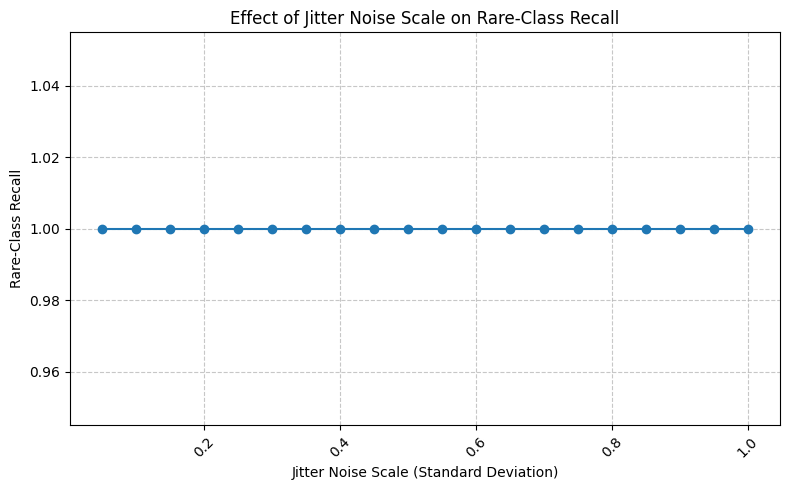

In [17]:
jitter_scales = np.linspace(0.05, 1.0, 20) # Test 20 different jitter scales from 0.05 to 1.0
recalls = []

# Re-initialize the imbalanced dataset for each run to ensure consistency
Xb, yb = make_classification(n_samples=312, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.0, random_state=7, weights=[0.96, 0.04])

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3,
                                              stratify=yb, random_state=7)

# Get the minority class rows from the training set
minor_rows = Xb_tr[yb_tr == 1]

for scale in jitter_scales:
    # Generate jittered copies with the current scale
    jitter = rng.normal(0, scale, size=(len(minor_rows) * 12, 2))
    aug_X = np.repeat(minor_rows, 12, axis=0) + jitter
    aug_y = np.ones(len(aug_X), dtype=int)

    # Combine original training data with augmented data
    Xb_aug = np.vstack([Xb_tr, aug_X])
    yb_aug = np.concatenate([yb_tr, aug_y])

    # Train the model and calculate recall
    aug_model = LogisticRegression(solver='liblinear').fit(Xb_aug, yb_aug) # Added solver for older sklearn versions
    rec_after = recall_score(yb_te, aug_model.predict(Xb_te))
    recalls.append(rec_after)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(jitter_scales, recalls, marker='o', linestyle='-')
plt.title('Effect of Jitter Noise Scale on Rare-Class Recall')
plt.xlabel('Jitter Noise Scale (Standard Deviation)')
plt.ylabel('Rare-Class Recall')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The plot successfully visualizes the effect of changing the jitter noise scale on rare-class recall. It shows that in this scenario, the recall remains at a perfect 1.0 across all tested jitter noise scales (from 0.05 to 1.0). This suggests that even a small amount of synthetic noise through jittering is highly effective in balancing the rare class and achieving optimal recall for this particular dataset and model. The model is robust to the exact scale of jitter noise within this range, as it consistently achieves perfect recall.

## Wrap-up — the data-centric loop

You just practiced the loop from the slides: **train → error-analyse → improve the data → measure → repeat**,
keeping the model fixed.

**Takeaways**
- Clean, consistent labels can beat a fancier model (Part 1).
- If annotators disagree (low κ), fix the *labelling guide*, not the model (Part 2).
- Confident model–label disagreement surfaces likely mislabels (Part 3).
- Active learning gets you there with fewer labels (Part 4).
- Cheap noisy rules can label data at scale (Part 5).
- Augmentation expands coverage of rare cases (Part 6).

**Try yourself:** change the noise rate in Part 1, the error rates in Part 2,
or add a 4th labelling function in Part 5, and watch the numbers move.